In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["MKL_CBWR"] = "COMPATIBLE"
os.environ["ATEN_CPU_CAPABILITY"] = "avx2"
os.environ["OMP_NUM_THREADS"] = os.environ["MKL_NUM_THREADS"] = os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["NPY_DISABLE_CPU_FEATURES"] = "AVX512F AVX512CD AVX512_KNL AVX512_KNM AVX512_SKX AVX512_CLX AVX512_CNL AVX512_ICL AVX512_SPR"
os.environ["OPENBLAS_CORETYPE"] = "Haswell"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import sys
sys.path.append("..")

In [2]:
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

import anndata as ad
import numpy as np
import os, random, numpy as np, torch
import mgw.mgw as mgw
import scanpy as sc
import squidpy as sq
from mgw import plotting

### Parameters

In [3]:
PCA_componet = 20
CCA_componet = 2
MSI_Top = 30

PHI_ARC = (128,256,256,128)
KNN_K= 30
DEFAULT_GW_PARAMS = dict(verbose=True, inner_maxit=2000, outer_maxit=2000, inner_tol=1e-8,   outer_tol=1e-8,   epsilon=1e-3)
DEFAULT_LR = 1e-3
DEFAULT_EPS = 1e-6
DEFAULT_ITER = 10_000
SEED = 0

In [4]:
EXP_PATH = None #specify the path to save your trained phi psi model (None: retrain without caching)
EXP_TAG = f'R114_CCA{CCA_componet}_demo' #specify the name of your experiment

### Load datasets


In [5]:
JOINT_PATH = "/scratch/gpfs/BRAPHAEL/ST_SM/adata_joint_R114_T_raw.h5ad"
joint = ad.read_h5ad(JOINT_PATH)
st = joint[:, joint.var["type"] == "ST"].copy()
msi = joint[:, joint.var["type"] == "SM"].copy()

### Preprocessing spatial metabolome dataset: select metabolites with high Moran's I

In [6]:
K = MSI_Top

sc.pp.normalize_total(msi, target_sum=1e3)

sq.gr.spatial_neighbors(msi, key_added='spatial')
sq.gr.spatial_autocorr(
    msi,
    mode="moran",
    genes=None,
    layer=None,
    n_jobs=8,
)
top_moran = (
    msi.uns["moranI"]
    .sort_values("I", ascending=False)
    .head(K)
)
msi.var["highly_variable_moranI"] = msi.var_names.isin(top_moran.index)

moran_df = msi.uns["moranI"]

if "names" in moran_df.columns:          
    ranked = moran_df.sort_values("I", ascending=False)["names"].head(K)
else:
    ranked = moran_df.sort_values("I", ascending=False).index[:K]

msi.var["highly_variable_moranI"] = msi.var_names.isin(ranked)

n_total = msi.shape[1]
n_keep  = int(msi.var["highly_variable_moranI"].sum())
print(f"Before: {msi.shape}  |  marked spatially variable: {n_keep}/{n_total}")

adata_sm = msi[:, msi.var["highly_variable_moranI"]].copy()

print("After: ", msi.shape)

adata_st = st.copy()
adata_sm = msi.copy()

Before: (2201, 1299)  |  marked spatially variable: 30/1299
After:  (2201, 1299)


## mgw.mgw_preprocess(A, B)

Prepares spatial and molecular features for alignment.

### Feature settings
| Parameter | Description |
|-----------|-------------|
| `PCA_comp` | PCA components for expression (default: 30) |
| `CCA_comp` | CCA components after feeler alignment (default: 3) |
| `use_cca_feeler` | Run a small exploratory GW + CCA step to improve alignment |
| `feeler_downsample` | Number of cells used for the feeler GW |
| `log1p_X`, `log1p_Z` | Apply log1p to raw counts |
| `use_pca_X`, `use_pca_Z` | Use PCA on each modality |

### Downsampling
| Parameter | Description |
|-----------|-------------|
| `max_obs_A`, `max_obs_B` | Cap number of cells (None = no limit) |

### Feeler variants
| Parameter | Description |
|-----------|-------------|
| `spatial_only` | Feeler uses spatial distances only |
| `feature_only` | Feeler uses feature distances only |

> If both are `False`, the feeler uses spatial × feature distances jointly.

### Other
| Parameter | Description |
|-----------|-------------|
| `verbose` | Print progress logs |

In [7]:
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp

def pca_from(adata, n_comps):
    a = adata.copy(); sc.pp.log1p(a); zc = not sp.issparse(a.X)
    if zc: sc.pp.scale(a, max_value=10)
    sc.tl.pca(a, n_comps=n_comps, zero_center=zc, svd_solver="arpack" if zc else "auto")
    return np.asarray(a.obsm["X_pca"], dtype=np.float64)

st_raw = joint[:, joint.var["type"] == "ST"].copy()
sm_raw = joint[:, joint.var["type"] == "SM"].copy()
X_rep, Z_rep = CCA(n_components=CCA_componet).fit_transform(
    StandardScaler().fit_transform(pca_from(st_raw, PCA_componet)),
    StandardScaler().fit_transform(pca_from(sm_raw, PCA_componet)))
pre = dict(xs=mgw._to_unit_square(st_raw.obsm["spatial"]), xs2=mgw._to_unit_square(sm_raw.obsm["spatial"]),
           X_rep=X_rep, Z_rep=Z_rep, config={})

## mgw.mgw_align_core(pre)

Trains neural fields φ, ψ, estimates Riemannian geodesics, and solves Gromov-Wasserstein.

### Neural network
| Parameter | Description |
|-----------|-------------|
| `widths` | Hidden layer sizes (default: (128, 256, 256, 128)) |
| `lr` | Learning rate |
| `niter` | Number of training steps |
| `print_every` | Log frequency |

### Geometry and graph
| Parameter | Description |
|-----------|-------------|
| `knn_k` | kNN graph size for geodesic computation (default: 12) |
| `geodesic_eps` | Finite-difference epsilon for the metric Jacobian |

### GW solver
| Parameter | Description |
|-----------|-------------|
| `gw_params` | Dict of OT solver settings (`epsilon`, tolerances, iterations) |

### Compute and saving
| Parameter | Description |
|-----------|-------------|
| `device` | `'cuda'` or `'cpu'` |
| `torch_default_dtype` | Use `torch.float64` for higher precision |
| `save_dir` | Directory to save neural fields and the GW coupling |
| `tag` | Suffix appended to saved filenames |

### Other
| Parameter | Description |
|-----------|-------------|
| `plot_net` | Plot neural field predictions vs. true features for a sanity check |
| `verbose` | Print progress logs |

[mgw.core] device=cuda dtype=torch.float64
[mgw.core] dims: E=2, F_M=2, F_N=2
[mgw.core] seed=0
[mgw.core] deterministic training (fused Adam, deterministic kernels)
[mgw.core] training φ, ψ
[train_phi] step=1000 loss=0.126075
[train_phi] step=2000 loss=0.135134
[train_phi] step=3000 loss=0.094694
[train_phi] step=4000 loss=0.078924
[train_phi] step=5000 loss=0.075742
[train_phi] step=6000 loss=0.069869
[train_phi] step=7000 loss=0.067771
[train_phi] step=8000 loss=0.064758
[train_phi] step=9000 loss=0.061415
[train_phi] step=10000 loss=0.060785
[train_phi] step=1000 loss=0.176022
[train_phi] step=2000 loss=0.129294
[train_phi] step=3000 loss=0.110295
[train_phi] step=4000 loss=0.104979
[train_phi] step=5000 loss=0.099250
[train_phi] step=6000 loss=0.112215
[train_phi] step=7000 loss=0.090880
[train_phi] step=8000 loss=0.087863
[train_phi] step=9000 loss=0.085927
[train_phi] step=10000 loss=0.084279


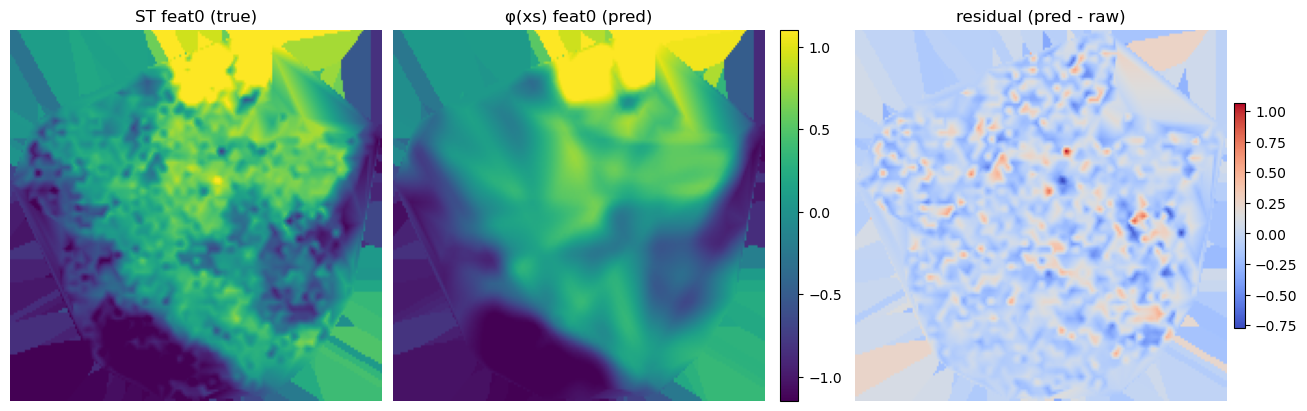

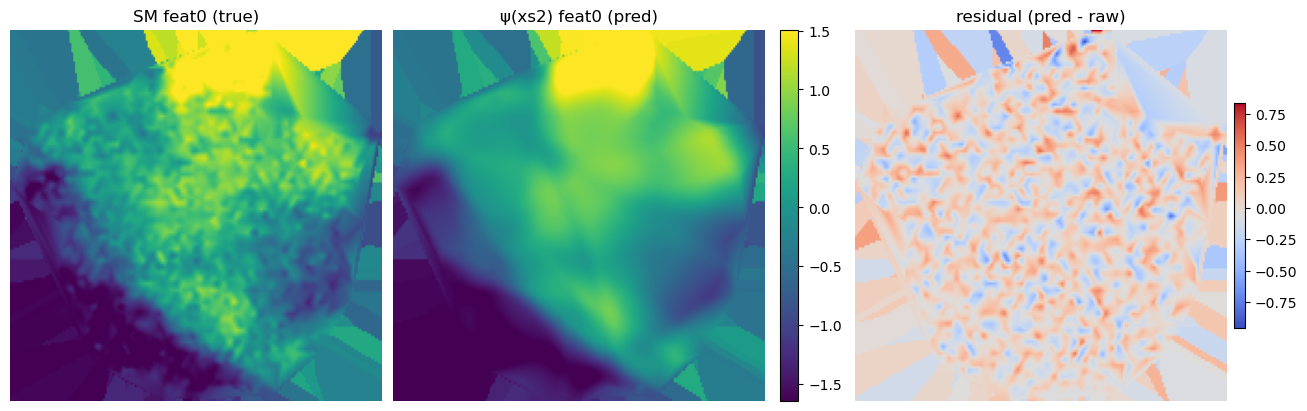

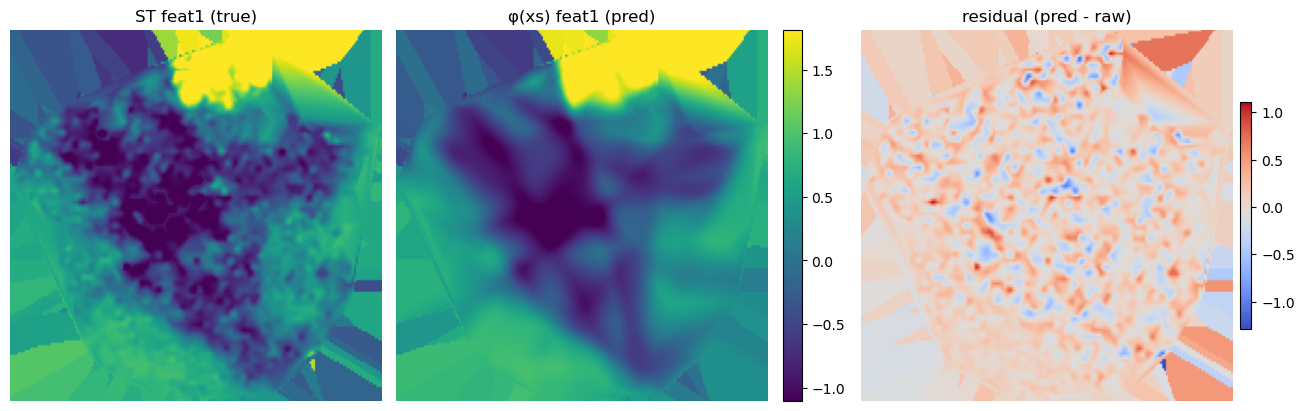

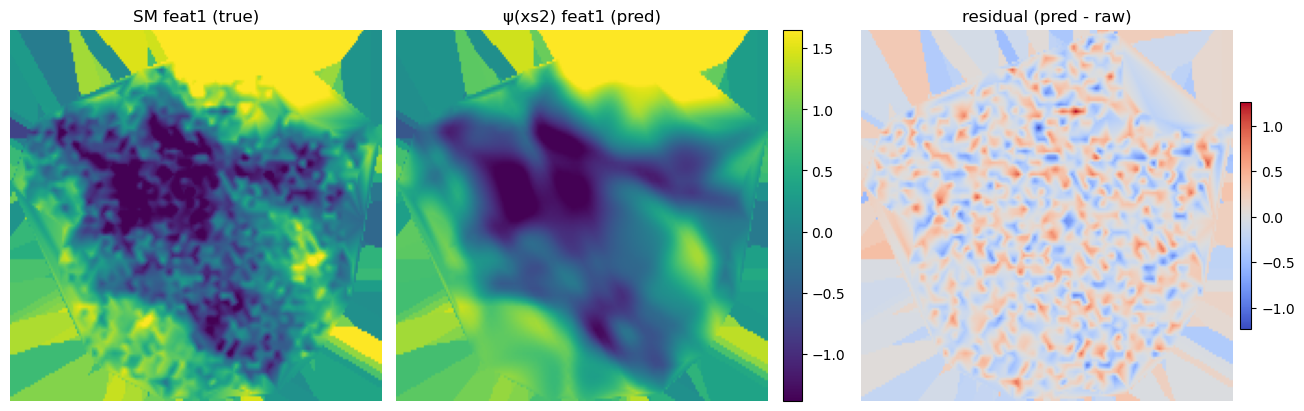

[mgw.core] pullback metrics & geodesics
Rescaling Jacobians by 55.425558465395525.
Rescaling Jacobians by 105.91680198592174.
[mgw.core] cost matrices: d^2 (cost_p=2)
[mgw.core] solving GW with {'verbose': True, 'inner_maxit': 2000, 'outer_maxit': 2000, 'inner_tol': 1e-08, 'outer_tol': 1e-08, 'epsilon': 0.001}
[mgw.core] coupling: shape=(2201, 2201), mass=1.000000


In [8]:
out = mgw.mgw_align_core(
        pre,
        widths=PHI_ARC,
        lr=DEFAULT_LR,
        niter=DEFAULT_ITER,
        knn_k=KNN_K,
        geodesic_eps=DEFAULT_EPS,
        save_dir=EXP_PATH, 
        tag=EXP_TAG, 
        verbose=True,
        plot_net=True, # zoom in to visually check if the two modalities shown similar pattern
        gw_params = DEFAULT_GW_PARAMS,
        seed=SEED,
        deterministic=True,
        n_restarts=1,
    )

### Visualize the coupling

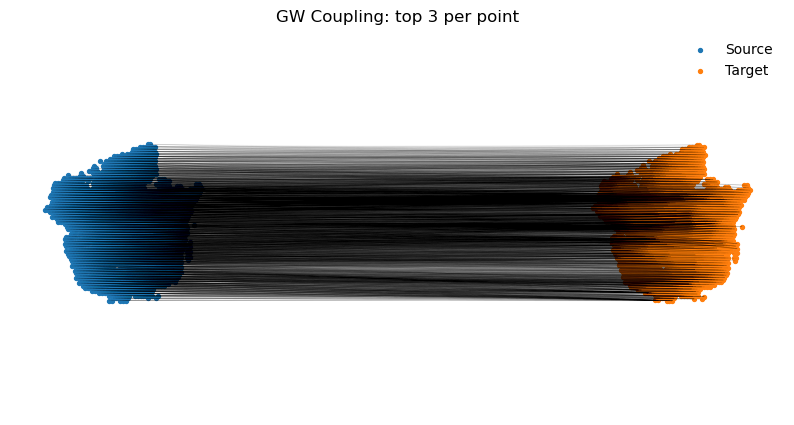

In [9]:
xs = out["xs"]
xs2 = out["xs2"]
P = out["P"]
xs_aligned, xt_aligned, R, tvec = plotting.procrustes_from_coupling(xs, xs2, P)
plotting.plot_alignment_lines_dense(xs_aligned, xt_aligned, P, alpha=0.05)

### Check the alignment 

In [10]:
Y = (P @ xs2) / P.sum(1, keepdims=True)
U, _, Vt = np.linalg.svd((xs - xs.mean(0)).T @ (Y - Y.mean(0)))
print(f"orientation det = {np.linalg.det(U @ Vt):+.0f}")

orientation det = +1


### Barycentric projection across modalities

Use `mgw.transfer` to project features from one spatial coordinate frame onto the other via the coupling `P`. Pass `P` to project onto the first dataset's grid, or `P.T` to project onto the second.

In [11]:
#RAW ST dataset
st

AnnData object with n_obs × n_vars = 2201 × 36601
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'name', 'type'
    uns: 'spatial'
    obsm: 'spatial'

In [12]:
#RAW SM dataset
msi

AnnData object with n_obs × n_vars = 2201 × 1299
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'name', 'type', 'highly_variable_moranI'
    uns: 'spatial', 'spatial_neighbors', 'moranI'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [13]:
# USE ST coordinates as base
adata_sm2st = mgw.transfer(st, msi, P)
adata_sm2st

AnnData object with n_obs × n_vars = 2201 × 37900
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'name', 'type', 'highly_variable_moranI'
    uns: 'spatial', 'joint_base', 'features'
    obsm: 'spatial', 'coupling_to_B'

In [14]:
# USE SM coordinates as base
adata_st2sm = mgw.transfer(msi, st, P.T)
adata_st2sm

AnnData object with n_obs × n_vars = 2201 × 37900
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'name', 'type', 'highly_variable_moranI'
    uns: 'spatial', 'spatial_neighbors', 'moranI', 'joint_base', 'features'
    obsm: 'spatial', 'coupling_to_B'
    obsp: 'spatial_connectivities', 'spatial_distances'